In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import date
 
from dotenv import load_dotenv
from sqlalchemy import create_engine
 
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
 
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
 
import optuna
import shap
import matplotlib.pyplot as plt

In [2]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)
 
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
 


In [3]:
df = pd.read_sql("SELECT * FROM gold.unified_deduplicated", engine)
print(f"Učitano: {len(df)} oglasa")
print(f"Kolone: {df.columns.tolist()}")


Učitano: 23680 oglasa
Kolone: ['stan_id', 'oglas_id', 'izvor', 'url', 'title', 'price_total', 'price_avg', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'dodatni_opis', 'lokacija', 'created_at']


In [4]:
null_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nNull vrednosti (%):")
print(null_values[null_values > 0].round(1))



Null vrednosti (%):
video_nadzor               84.1
podrum                     79.6
garaza                     75.5
tip_objekta                73.5
linije_gradskog_prevoza    72.2
parking                    59.9
internet                   55.3
oglasivac                  54.2
ukupna_spratnost           51.3
klima                      48.4
uknjizen                   46.1
lift                       43.6
interfon                   34.6
stanje_objekta             25.6
terasa                     23.7
tip_nekretnine             15.6
datum_objave               13.4
grejanje                    7.0
sprat                       6.1
lokacija                    1.9
dodatni_opis                0.1
title                       0.0
price_per_m2                0.0
dtype: float64


In [5]:
# ── FILTRIRANJE — samo 2025+ ───────────────────────────────────────────────────
df["datum_objave"] = pd.to_datetime(df["datum_objave"])
n_pre = len(df)
df = df[df["datum_objave"] >= "2025-01-01"].copy()
print(f"\nOdbačeno pre 2025: {n_pre - len(df)} | Ostalo: {len(df)}")
print(f"Raspon: {df['datum_objave'].min().date()} → {df['datum_objave'].max().date()}")



Odbačeno pre 2025: 3787 | Ostalo: 19893
Raspon: 2025-01-05 → 2026-05-04


In [6]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Cena po m² (provera konzistentnosti sa originalnom kolonom)
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]
df["razlika_abs"] = (df["price_per_m2"] - df["price_per_m2_cal"]).abs()
print(f"\nCena se razlikuje za >= 1 EUR/m²: {(df['razlika_abs'] >= 1).sum()} oglasa")



Cena se razlikuje za >= 1 EUR/m²: 8606 oglasa


In [7]:
mask_sprat = (
    df["sprat"].notna() &
    df["ukupna_spratnost"].notna() &
    (df["ukupna_spratnost"] != 0)
)
df["sprat_ratio"] = np.where(
    mask_sprat,
    df["sprat"] / df["ukupna_spratnost"],
    np.nan
)


In [8]:
n_pre = len(df)
df = df[df["sprat_ratio"].isna() | df["sprat_ratio"].between(0, 1)].copy()
print(f"Odbačeno sprat_ratio > 1: {n_pre - len(df)} oglasa | Ostalo: {len(df)}")
 
# Amenity score
bool_cols = ["uknjizen", "terasa", "interfon", "klima", "video_nadzor",
             "internet", "parking", "garaza", "lift", "podrum"]
df["amenity_score"] = df[bool_cols].sum(axis=1)
 
# Vremenske feature-e — umesto starost_oglasa (koji leakuje poziciju u splitu)
df["mesec"]     = df["datum_objave"].dt.month
df["kvartal"]   = df["datum_objave"].dt.quarter
df["godina"]    = df["datum_objave"].dt.year
df["mesec_sin"] = np.sin(2 * np.pi * df["mesec"] / 12)
df["mesec_cos"] = np.cos(2 * np.pi * df["mesec"] / 12)
 
# Lokacija: 'Nepoznato' → NaN
df["lokacija"] = df["lokacija"].replace("Nepoznato", None)

Odbačeno sprat_ratio > 1: 47 oglasa | Ostalo: 19846


In [9]:
# ── TEMPORAL SPLIT 80 / 10 / 10 ───────────────────────────────────────────────
df = df.sort_values("datum_objave").reset_index(drop=True)
 
n       = len(df)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)
 
train = df.iloc[:n_train].copy()
val   = df.iloc[n_train : n_train + n_val].copy()
test  = df.iloc[n_train + n_val :].copy()
 
print(f"\nTrain: {len(train):>6} | do:  {train['datum_objave'].max().date()}")
print(f"Val:   {len(val):>6} | {val['datum_objave'].min().date()} → {val['datum_objave'].max().date()}")
print(f"Test:  {len(test):>6} | od:  {test['datum_objave'].min().date()}")


Train:  15876 | do:  2026-04-22
Val:     1984 | 2026-04-22 → 2026-04-27
Test:    1986 | od:  2026-04-27


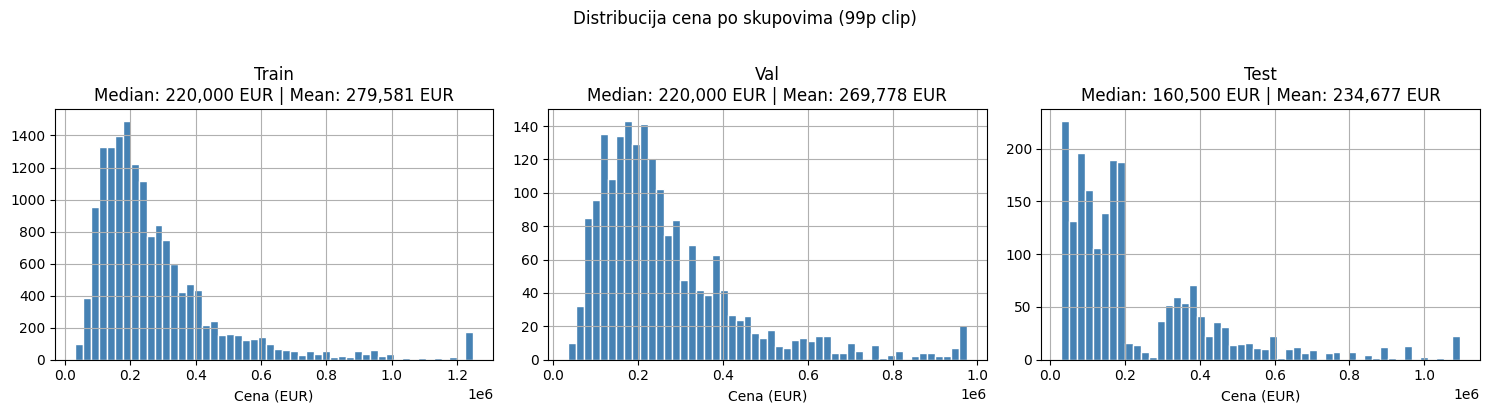

In [10]:
# Distribucija cena po skupovima
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, split) in zip(axes, [("Train", train), ("Val", val), ("Test", test)]):
    clip = split["price_total"].quantile(0.99)
    split["price_total"].clip(upper=clip).hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(
        f"{name}\n"
        f"Median: {split['price_total'].median():,.0f} EUR | "
        f"Mean: {split['price_total'].mean():,.0f} EUR"
    )
    ax.set_xlabel("Cena (EUR)")
plt.suptitle("Distribucija cena po skupovima (99p clip)", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── TARGET ENCODING ───────────────────────────────────────────────────────────
encoder = ce.TargetEncoder(cols=["lokacija"])
train["lokacija_encoded"] = encoder.fit_transform(train["lokacija"], train["price_total"])
val["lokacija_encoded"]   = encoder.transform(val["lokacija"])
test["lokacija_encoded"]  = encoder.transform(test["lokacija"])

In [12]:
# ── FEATURE COLS ──────────────────────────────────────────────────────────────
num_cols = [
    "kvadratura", "broj_soba", "sprat", "ukupna_spratnost",
    "sprat_ratio", "amenity_score",
    "mesec_sin", "mesec_cos", "kvartal", "godina",
    "lokacija_encoded",
    "terasa", "parking", "garaza", "lift", "podrum",
    "internet", "klima", "interfon", "video_nadzor", "uknjizen",
]
cat_cols = ["stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine"]
feature_cols = num_cols + cat_cols
 
X_train = train[feature_cols].copy()
X_val   = val[feature_cols].copy()
X_test  = test[feature_cols].copy()
 
Y_train = train["price_total"]
Y_val   = val["price_total"]
Y_test  = test["price_total"]
 
print(f"\nFeatures: {len(feature_cols)} | Train shape: {X_train.shape}")


Features: 25 | Train shape: (15876, 25)


In [13]:
# ── TIPOVI ZA LGBM ────────────────────────────────────────────────────────────
def prep_lgbm(X):
    X = X.copy()
    for col in cat_cols:
        X[col] = X[col].fillna("Unknown").astype("category")
    for col in bool_cols:
        if col in X.columns:
            X[col] = X[col].astype(float)
    X["amenity_score"] = X["amenity_score"].astype(float)
    return X
 
X_train_lgbm = prep_lgbm(X_train)
X_val_lgbm   = prep_lgbm(X_val)
X_test_lgbm  = prep_lgbm(X_test)
 
 
# ── HELPER: evaluacija ─────────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):,.0f} EUR")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):,.0f} EUR")
    print(f"R²:   {r2_score(y_true, y_pred):.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 15876, number of used features: 25
[LightGBM] [Info] Start training from score 279581.441736

=== LightGBM bazni — VAL ===
MAE:  45,420 EUR
RMSE: 73,126 EUR
R²:   0.844

=== LightGBM bazni — TEST ===
MAE:  96,082 EUR
RMSE: 153,780 EUR
R²:   0.541

Računam SHAP vrednosti...


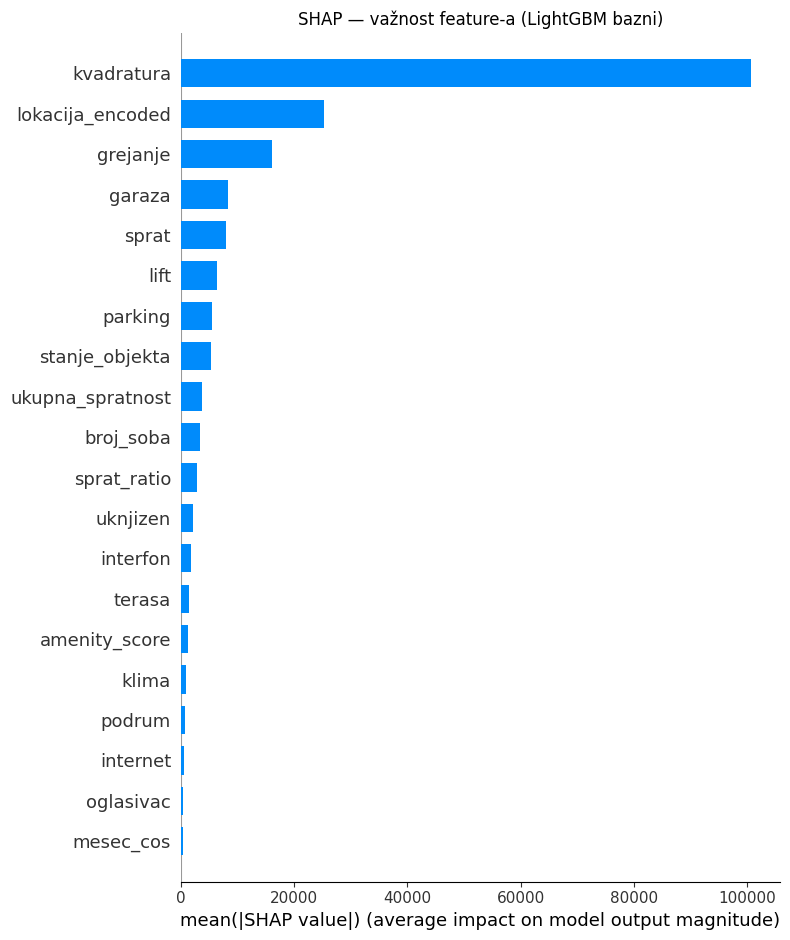

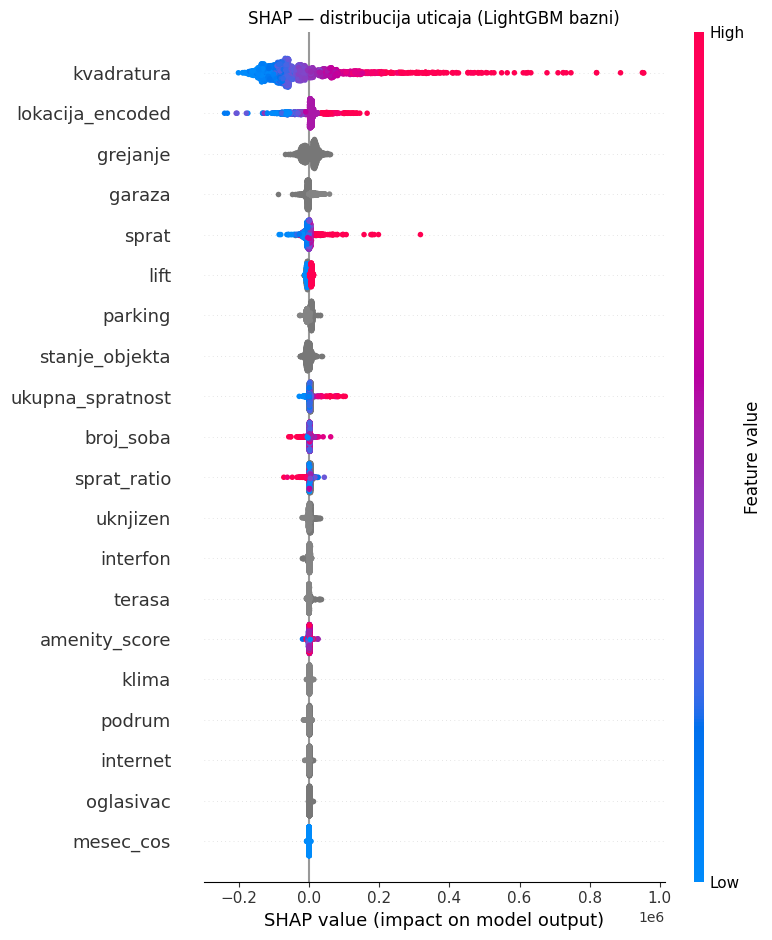

In [14]:
# 1. LIGHTGBM — BAZNI MODEL
# ══════════════════════════════════════════════════════════════════════════════
lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=1)
lgbm_base.fit(X_train_lgbm, Y_train)
 
evaluate("LightGBM bazni — VAL",  Y_val,  lgbm_base.predict(X_val_lgbm))
evaluate("LightGBM bazni — TEST", Y_test, lgbm_base.predict(X_test_lgbm))
 
 
# ── SHAP — važnost feature-a ───────────────────────────────────────────────────
print("\nRačunam SHAP vrednosti...")
explainer   = shap.TreeExplainer(lgbm_base)
shap_values = explainer.shap_values(X_val_lgbm)
 
plt.figure()
shap.summary_plot(shap_values, X_val_lgbm, plot_type="bar", show=False)
plt.title("SHAP — važnost feature-a (LightGBM bazni)")
plt.tight_layout()
plt.show()
 
shap.summary_plot(shap_values, X_val_lgbm, show=False)
plt.title("SHAP — distribucija uticaja (LightGBM bazni)")
plt.tight_layout()
plt.show()

In [15]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": 1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train_lgbm, Y_train)
    return mean_absolute_error(Y_val, m.predict(X_val_lgbm))

In [16]:
print("\nOptuna pretraga (50 trials)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
 
print(f"Najbolji MAE (val): {study.best_value:,.0f} EUR")
print(f"Parametri: {study.best_params}")

[I 2026-05-10 18:51:38,952] A new study created in memory with name: no-name-5806b931-86a7-4c9e-a32d-6432f656e08a



Optuna pretraga (50 trials)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001430 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 15876, number of used features: 25
[LightGBM] [Info] Start training from score 279581.441736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

[I 2026-05-10 18:51:39,839] Trial 0 finished with value: 46659.013834555764 and parameters: {'n_estimators': 864, 'max_depth': 7, 'num_leaves': 122, 'learning_rate': 0.013760279115933164, 'min_child_samples': 88, 'subsample': 0.7182002319017109, 'colsample_bytree': 0.7480705302776247}. Best is trial 0 with value: 46659.013834555764.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 15876, number of used features: 25
[LightGBM] [Info] Start training from score 279581.441736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[I 2026-05-10 18:51:40,249] Trial 1 finished with value: 49290.94386561297 and parameters: {'n_estimators': 502, 'max_depth': 5, 'num_leaves': 113, 'learning_rate': 0.02064962790980606, 'min_child_samples': 97, 'subsample': 0.6315518338093449, 'colsample_bytree': 0.6205681591132027}. Best is trial 0 with value: 46659.013834555764.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 18:52:10,027] Trial 48 finished with value: 38640.430992278016 and parameters: {'n_estimators': 544, 'max_depth': 6, 'num_leaves': 199, 'learning_rate': 0.07833786778032799, 'min_child_samples': 13, 'subsample': 0.92951391001646, 'colsample_bytree': 0.7661001367656062}. Best is trial 30 with value: 34059.54453279635.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 18:52:10,411] Trial 49 finished with value: 41807.973510858996 and parameters: {'n_estimators': 492, 'max_depth': 5, 'num_leaves': 176, 'learning_rate': 0.09079994246654774, 'min_child_samples': 23, 'subsample': 0.9987557806972795, 'colsample_bytree': 0.8747451454570282}. Best is trial 30 with value: 34059.54453279635.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [17]:
lgbm_best = lgb.LGBMRegressor(**study.best_params, random_state=42, n_jobs=1)
lgbm_best.fit(X_train_lgbm, Y_train)
 
evaluate("LightGBM optimizovan — VAL",  Y_val,  lgbm_best.predict(X_val_lgbm))
evaluate("LightGBM optimizovan — TEST", Y_test, lgbm_best.predict(X_test_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 15876, number of used features: 25
[LightGBM] [Info] Start training from score 279581.441736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_17661/2840380022.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


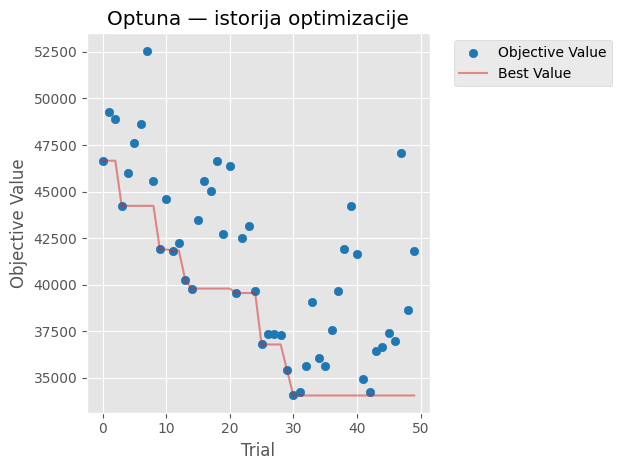

/var/folders/8n/t9qxl3yn7615w9l35j5w328m0000gn/T/ipykernel_17661/2840380022.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


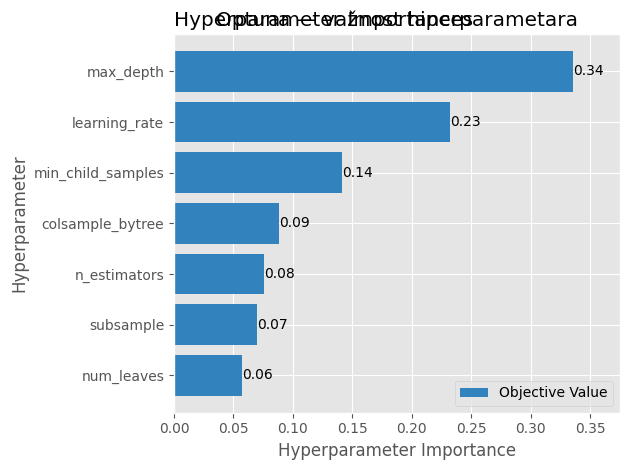

In [18]:
# Optuna vizualizacije
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna — istorija optimizacije")
plt.tight_layout()
plt.show()
 
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna — važnost hiperparametara")
plt.tight_layout()
plt.show()

In [19]:
# 3. CATBOOST
# ══════════════════════════════════════════════════════════════════════════════
# CatBoost prima kategoričke kolone kao string — bez prethodnog enkodiranja
X_train_cat_cb = X_train.copy()
X_val_cat_cb   = X_val.copy()
X_test_cat_cb  = X_test.copy()
 
for col in cat_cols:
    X_train_cat_cb[col] = X_train_cat_cb[col].fillna("Unknown").astype(str)
    X_val_cat_cb[col]   = X_val_cat_cb[col].fillna("Unknown").astype(str)
    X_test_cat_cb[col]  = X_test_cat_cb[col].fillna("Unknown").astype(str)
 
cat_model = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_cols)
cat_model.fit(X_train_cat_cb, Y_train)
 
evaluate("CatBoost — VAL",  Y_val,  cat_model.predict(X_val_cat_cb))
evaluate("CatBoost — TEST", Y_test, cat_model.predict(X_test_cat_cb))


=== CatBoost — VAL ===
MAE:  44,761 EUR
RMSE: 71,791 EUR
R²:   0.850

=== CatBoost — TEST ===
MAE:  93,272 EUR
RMSE: 149,057 EUR
R²:   0.568


In [20]:
# 4. RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
# RF ne podržava kategoričke kolone direktno — koristimo LabelEncoder
X_train_rf = X_train.copy()
X_val_rf   = X_val.copy()
X_test_rf  = X_test.copy()
 
le = LabelEncoder()
for col in cat_cols:
    # fit samo na train skupu
    X_train_rf[col] = le.fit_transform(X_train_rf[col].fillna("Unknown").astype(str))
    # transform za val i test — kategorije kojih nema u train mapiramo na "Unknown"
    val_vals  = X_val_rf[col].fillna("Unknown").astype(str)
    test_vals = X_test_rf[col].fillna("Unknown").astype(str)
    known     = set(le.classes_)
    X_val_rf[col]  = le.transform(val_vals.where(val_vals.isin(known), "Unknown"))
    X_test_rf[col] = le.transform(test_vals.where(test_vals.isin(known), "Unknown"))
 
for col in bool_cols:
    if col in X_train_rf.columns:
        X_train_rf[col] = X_train_rf[col].astype(float)
        X_val_rf[col]   = X_val_rf[col].astype(float)
        X_test_rf[col]  = X_test_rf[col].astype(float)
 
rf_model = RandomForestRegressor(random_state=42, n_jobs=1)
rf_model.fit(X_train_rf, Y_train)
 
evaluate("Random Forest — VAL",  Y_val,  rf_model.predict(X_val_rf))
evaluate("Random Forest — TEST", Y_test, rf_model.predict(X_test_rf))


=== Random Forest — VAL ===
MAE:  29,038 EUR
RMSE: 58,852 EUR
R²:   0.899

=== Random Forest — TEST ===
MAE:  83,461 EUR
RMSE: 146,841 EUR
R²:   0.581


In [21]:
# ── FINALNA TABELA ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("POREĐENJE SVIH MODELA — TEST SET")
print("=" * 65)
 
results = []
for name, (model, X) in {
    "LightGBM bazni":       (lgbm_base, X_test_lgbm),
    "LightGBM optimizovan": (lgbm_best, X_test_lgbm),
    "CatBoost":             (cat_model, X_test_cat_cb),
    "Random Forest":        (rf_model,  X_test_rf),
}.items():
    y_pred = model.predict(X)
    results.append({
        "Model": name,
        "MAE":   f"{mean_absolute_error(Y_test, y_pred):,.0f} EUR",
        "RMSE":  f"{root_mean_squared_error(Y_test, y_pred):,.0f} EUR",
        "R²":    f"{r2_score(Y_test, y_pred):.3f}",
    })
 
print(pd.DataFrame(results).to_string(index=False))


POREĐENJE SVIH MODELA — TEST SET
               Model        MAE        RMSE    R²
      LightGBM bazni 96,082 EUR 153,780 EUR 0.541
LightGBM optimizovan 87,074 EUR 148,097 EUR 0.574
            CatBoost 93,272 EUR 149,057 EUR 0.568
       Random Forest 83,461 EUR 146,841 EUR 0.581
